# Exploring precision and recall

The goal of this second notebook is to understand precision-recall in the context of classifiers.

 * Use Amazon review data in its entirety.
 * Train a logistic regression model.
 * Explore various evaluation metrics: accuracy, confusion matrix, precision, recall.
 * Explore how various metrics can be combined to produce a cost of making an error.
 * Explore precision and recall curves.
 

## Fire up Scikit-learn, Pandas and Numpy

In [1]:
# Imoorting pandas as pd
import pandas as pd
# Imoorting numpy as np 
import numpy as np
# Imoorting sklearn
from sklearn import datasets, linear_model

# Load amazon review dataset

In [2]:
# Reading the CSV file
products = pd.read_csv('amazon_baby.csv')
products

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5
...,...,...,...
183526,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5
183527,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5
183528,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5
183529,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5


# Extract word counts and sentiments

As in the first assignment of this course, we compute the word counts for individual words and extract positive and negative sentiments from ratings. To summarize, we perform the following:

1. Remove punctuation.
2. Remove reviews with "neutral" sentiment (rating 3).
3. Set reviews with rating 4 or more to be positive and those with 2 or less to be negative.

In [3]:
# Checking the DataFrame
products.head()

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5


#### To do

Turn nan to nothing. Turning nan to nothing before removing punctuation is critical.

In [4]:
## Your Code

# Replacing missing values in the DataFrame
products = products.replace('',np.nan,regex = True)
products

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5
...,...,...,...
183526,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5
183527,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5
183528,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5
183529,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5


In [5]:
# Replacing NaN values in the DataFrame
products = products.replace(np.nan, 'Nothing')
products

,name,review,rating
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5
...,...,...,...
183526,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5
183527,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5
183528,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5
183529,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5


In [6]:
# Remove punctuation
def remove_punctuation(text):
    import string
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

#### To do 

1. Convert "review" to strign using astype(str)
2. apply the above function (remove_punctuation) to each entry
3. add it to a new columns "review_clean"

In [7]:
## Your Code

# Changing Column Datatype
products['review'] = products['review'].astype(str)

In [8]:
# Using For Loop for the range of row numbers of the DataFrame
for i in range(products.shape[0]):
# Applying remove_punctuation function
    products.loc[i,'review_clean'] = remove_punctuation(products.loc[i,'review'])

In [9]:
products.head()

,name,review,rating,review_clean
0,Planetwise Flannel Wipes,"These flannel wipes are OK, but in my opinion ...",3,These flannel wipes are OK but in my opinion n...
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...


#### To do
Remove reviews with "neutral" sentiment (rating 3).

In [10]:
## Your code

# Removing reviews with "Neutral" sentiment
products.drop(products[products['rating'] == 3].index, inplace = True)

In [11]:
# Checking the DataFrame
products.head()

,name,review,rating,review_clean
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...
5,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,When the Binky Fairy came to our house we didn...


#### To do 
#### Positive sentiment to +1 and negative sentiment to -1

Now, we will assign reviews with a rating of 4 or higher to be positive reviews, while the ones with rating of 2 or lower are negative. For the sentiment column, we use +1 for the positive class label and -1 for the negative class label. A good way is to create an anonymous function that converts a rating into a class label and then apply that function to every element in the rating column. 

Also show the count of newly created variable

In [12]:
## Your code
# Creating a function to compute negative, neutral and positive sentiment
def getSentiment(rating):
    if rating >= 4:
       return +1
    else:
       return -1
products['Sentiment'] = products['rating'].apply(getSentiment)

In [13]:
# Counting distinct values in column
products['Sentiment'].value_counts()

 1    140259
-1     26493
Name: Sentiment, dtype: int64

In [14]:
# Checking the DataFrame
products.head()

,name,review,rating,review_clean,Sentiment
1,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...,1
2,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...,1
3,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...,1
4,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...,1
5,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,When the Binky Fairy came to our house we didn...,1


Now, we can see that the dataset contains an extra column called sentiment which is either positive (+1) or negative (-1).

# Split into training and test sets

Let's perform a train/test split. 
Generally what you do is use train test split function from sklern directly. Here however we are going to use aa slightly different approach. We will use with do this 80:20 split using index of the dataset so you know when we use such functions what exaclty is going behind this.

#### To do 

1. Reset the index of your dataset. This step is important as when you drop obseravtion your index number and observation number are not aligned anymore.
2. create 2 sepearte sequence for train and test
3. use that sequence to do the split (This is done for you)

In [15]:
## Your Code

# Resetting the index
products = products.reset_index(drop=True)
products

,name,review,rating,review_clean,Sentiment
0,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...,1
1,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...,1
2,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...,1
3,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...,1
4,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,When the Binky Fairy came to our house we didn...,1
...,...,...,...,...,...
166747,Baby Teething Necklace for Mom Pretty Donut Sh...,Such a great idea! very handy to have and look...,5,Such a great idea very handy to have and look ...,1
166748,Baby Teething Necklace for Mom Pretty Donut Sh...,This product rocks! It is a great blend of fu...,5,This product rocks It is a great blend of fun...,1
166749,Abstract 2 PK Baby / Toddler Training Cup (Pink),This item looks great and cool for my kids.......,5,This item looks great and cool for my kidsI kn...,1
166750,"Baby Food Freezer Tray - Bacteria Resistant, B...",I am extremely happy with this product. I have...,5,I am extremely happy with this product I have ...,1


In [16]:
## Your Code
# Calculating 80% of Total Number of Rows
Tr = products.shape[0]*0.8
Tr

133401.6

In [17]:
# Sequence for train data
traindata = products[0:133402].index.tolist()

In [18]:
# Calculating 20% of Total Number of Rows
Te = products.shape[0]*0.2
Te

33350.4

In [19]:
# Sequence for test data
testdata = products[133402:].index.tolist()

In [20]:
#pull train and test data from products data using the index docs
train_data = products.iloc[traindata]
test_data = products.iloc[testdata]

In [21]:
print(len(train_data))
print(len(test_data))

133402
33350


In [22]:
train_data

,name,review,rating,review_clean,Sentiment
0,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...,1
1,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...,1
2,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...,1
3,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...,1
4,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,When the Binky Fairy came to our house we didn...,1
...,...,...,...,...,...
133397,"Playtex Flip Top Snacker with Twist \'N Click,...",Got this for our 18 month old and it works qui...,4,Got this for our 18 month old and it works qui...,1
133398,"Playtex Flip Top Snacker with Twist \'N Click,...",I really like this travel cup. I love the lid...,4,I really like this travel cup I love the lid ...,1
133399,Playtex Diaper Genie On The Go Dispenser Refills,I am happy with these bags and the despenser. ...,5,I am happy with these bags and the despenser I...,1
133400,Playtex Diaper Genie On The Go Dispenser Refills,"Love the product, but NOT the price. I bought ...",2,Love the product but NOT the price I bought qu...,-1


In [23]:
train_data['Sentiment'].isnull().sum()

0

# Build the word count vector for each review

We will now compute the word count for each word that appears in the reviews. A vector consisting of word counts is often referred to as bag-of-word features. Since most words occur in only a few reviews, word count vectors are sparse. For this reason, scikit-learn and many other tools use sparse matrices to store a collection of word count vectors. Refer to appropriate manuals to produce sparse word count vectors. General steps for extracting word count vectors are as follows:

Learn a vocabulary (set of all words) from the training data. Only the words that show up in the training data will be considered for feature extraction.
Compute the occurrences of the words in each review and collect them into a row vector.
Build a sparse matrix where each row is the word count vector for the corresponding review. Call this matrix train_matrix.
Using the same mapping between words and columns, convert the test data into a sparse matrix test_matrix.
The following cell uses CountVectorizer in scikit-learn. Notice the token_pattern argument in the constructor.

In [24]:
train_data['review_clean'].head()

0    it came early and was not disappointed i love ...
1    Very soft and comfortable and warmer than it l...
2    This is a product well worth the purchase  I h...
3    All of my kids have cried nonstop when I tried...
4    When the Binky Fairy came to our house we didn...
Name: review_clean, dtype: object

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(token_pattern=r'\b\w+\b')

#### To do 
Above step essentially uses this token pattern to keep single-letter words and the learn vocabulary from the training data and assign columns to words.
Your job is to 

1. Then First convert the training data into a sparse matrix using fit_transform method
2. Second, convert the test data into a sparse matrix, using the same word-column mapping (using transform method)

In [26]:
## Your Code
# fit the train_matrix with the vectorizer
train_matrix = vectorizer.fit_transform(train_data.review_clean)
train_matrix

<133402x122041 sparse matrix of type '<class 'numpy.int64'>'
	with 7487304 stored elements in Compressed Sparse Row format>

In [27]:
# fit the test_matrix with the vectorizer
test_matrix = vectorizer.transform(test_data.review_clean)
test_matrix

<33350x122041 sparse matrix of type '<class 'numpy.int64'>'
	with 1656736 stored elements in Compressed Sparse Row format>

In [28]:
print(train_matrix.shape)
print(test_matrix.shape)

(133402, 122041)
(33350, 122041)


In [29]:
train_matrix

<133402x122041 sparse matrix of type '<class 'numpy.int64'>'
	with 7487304 stored elements in Compressed Sparse Row format>

# Train a sentiment classifier with logistic regression

Learn a logistic regression classifier using the training data. If you are using scikit-learn, you should create an instance of the LogisticRegression class and then call the method fit() to train the classifier. This model should use the sparse word count matrix (train_matrix) as features and the column sentiment of train_data as the target. Use the default values for other parameters. Call this model model.

In [30]:
np.isnan(train_data['Sentiment']).head()

0    False
1    False
2    False
3    False
4    False
Name: Sentiment, dtype: bool

In [31]:
train_data.head()

,name,review,rating,review_clean,Sentiment
0,Planetwise Wipe Pouch,it came early and was not disappointed. i love...,5,it came early and was not disappointed i love ...,1
1,Annas Dream Full Quilt with 2 Shams,Very soft and comfortable and warmer than it l...,5,Very soft and comfortable and warmer than it l...,1
2,Stop Pacifier Sucking without tears with Thumb...,This is a product well worth the purchase. I ...,5,This is a product well worth the purchase I h...,1
3,Stop Pacifier Sucking without tears with Thumb...,All of my kids have cried non-stop when I trie...,5,All of my kids have cried nonstop when I tried...,1
4,Stop Pacifier Sucking without tears with Thumb...,"When the Binky Fairy came to our house, we did...",5,When the Binky Fairy came to our house we didn...,1


#### To do

#Step 1. Import the model I want to use

#Step 2. Make an instance of the Model

#Step 3. Training the model on the data, storing the information learned from the data

In [32]:
## Your Code
# Importing logistic regression
from sklearn.linear_model import LogisticRegression
# Creating an instance of the Model
model = LogisticRegression(random_state = 0)
# Fitting logistic regression to training set
model.fit(train_matrix, train_data['Sentiment'])

C:\Users\sangita\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

# Model Evaluation

We will explore the advanced model evaluation concepts that were discussed in the lectures.

## Accuracy

One performance metric we will use for our more advanced exploration is accuracy, which we have seen many times in past assignments.  Recall that the accuracy is given by

$$
\mbox{accuracy} = \frac{\mbox{# correctly classified data points}}{\mbox{# total data points}}
$$


#### To do
Compute the accuracy on the test set using your tool of choice. If you are using scikit-learn, you can use the pre-defined method accuracy_score:

In [33]:
# Prediction
y_pred = model.predict(test_matrix)

In [34]:
## Your Code

# Computing the accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_data['Sentiment'], y_pred)
print('accuracy score = ',accuracy)

accuracy score =  0.9369715142428786


## Baseline: Majority class prediction

Generally we use the **majority class classifier** as a baseline (i.e reference) model for a point of comparison with a more sophisticated classifier. The majority classifier model predicts the majority class for all data points. 

Typically, a good model should beat the majority class classifier. Since the majority class in this dataset is the positive class (i.e., there are more positive than negative reviews), the accuracy of the majority class classifier can be computed as follows:

In [35]:
baseline = len(test_data[test_data['Sentiment'] == 1])/len(test_data)
print ("Baseline accuracy (majority class classifier): %s" % baseline)

Baseline accuracy (majority class classifier): 0.8551124437781109


#### To do

** Quiz Question:** Using accuracy as the evaluation metric, was our **logistic regression model** better than the baseline (majority class classifier)?

YES

## Confusion Matrix

The accuracy, while convenient, does not tell the whole story. For a fuller picture, we turn to the **confusion matrix**. In the case of binary classification, the confusion matrix is a 2-by-2 matrix laying out correct and incorrect predictions made in each label as follows:
```
              +---------------------------------------------+
              |                Predicted label              |
              +----------------------+----------------------+
              |          (+1)        |         (-1)         |
+-------+-----+----------------------+----------------------+
| True  |(+1) | # of true positives  | # of false negatives |
| label +-----+----------------------+----------------------+
|       |(-1) | # of false positives | # of true negatives  |
+-------+-----+----------------------+----------------------+
```

#### To do 

Print out the confusion matrix -

In [36]:
## Your Code

from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(test_data['Sentiment'], y_pred)


print (' target_label | predicted_label | count ')
print ('--------------+-----------------+-------')
for i, target_label in enumerate(model.classes_):
    for j, predicted_label in enumerate(model.classes_):
        print ('{0:^13} | {1:^15} | {2:5d}'.format(target_label, predicted_label, cmat[i,j]))

 target_label | predicted_label | count 
--------------+-----------------+-------
     -1       |       -1        |  3461
     -1       |        1        |  1371
      1       |       -1        |   731
      1       |        1        | 27787


IMPORTANT. In one way or another, make sure to print out the predicted label and the true label for each and every entry of the confusion matrix. This way, we don't mistake one type of mistake for another. The cell above produces the following output:

target_label | predicted_label | count 
--------------+-----------------+-------
     -1       |       -1        |  3449
     -1       |        1        |  1383
      1       |       -1        |   723
      1       |        1        | 27796

#### Quiz Question: 

How many predicted values in the test set are false positives?

1371 predicted values in the test set are false positives

## Computing the cost of mistakes


Put yourself in the shoes of a manufacturer that sells a baby product on Amazon.com and you want to monitor your product's reviews in order to respond to complaints.  Even a few negative reviews may generate a lot of bad publicity about the product. So you don't want to miss any reviews with negative sentiments --- you'd rather put up with false alarms about potentially negative reviews instead of missing negative reviews entirely. In other words, **false positives cost more than false negatives**. (It may be the other way around for other scenarios, but let's stick with the manufacturer's scenario for now.)

Suppose you know the costs involved in each kind of mistake: 
1. \$100 for each false positive.
2. \$1 for each false negative.
3. Correctly classified reviews incur no cost.

**Quiz Question**: Given the stipulation, what is the cost associated with the logistic regression classifier's performance on the **test set**?

In [37]:
FP = 1371
FN = 731
print (100*FP +1*FN)

137831


## Precision and Recall

You may not have exact dollar amounts for each kind of mistake. Instead, you may simply prefer to reduce the percentage of false positives to be less than, say, 3.5% of all positive predictions. This is where **precision** comes in:

$$
[\text{precision}] = \frac{[\text{# positive data points with positive predicitions}]}{\text{[# all data points with positive predictions]}} = \frac{[\text{# true positives}]}{[\text{# true positives}] + [\text{# false positives}]}
$$

#### To do

First, let us compute the precision of the logistic regression classifier on the test_data. Scikit-learn provides a predefined method for computing precision. (Consult appropriate manuals if you are using other tools.)

In [38]:
# Computing precision score
from sklearn.metrics import precision_score
precision_score(test_data['Sentiment'], y_pred, average=None)

array([0.82562023, 0.95298031])

Quiz Question: Out of all reviews in the test set that are predicted to be positive, what fraction of them are false positives? (Round to the second decimal place e.g. 0.25)

In [39]:
## Your Code

# Calculating fraction of false positives
true_positives = 27787
false_positives = 1371
Total_reviews_predicted_to_be_positive = (true_positives + false_positives)
Fraction_of_false_positives = (false_positives / Total_reviews_predicted_to_be_positive)
print(f"Fraction of false positives is {Fraction_of_false_positives:.2f}")

Fraction of false positives is 0.05


A complementary metric is **recall**, which measures the ratio between the number of true positives and that of (ground-truth) positive reviews:

$$
[\text{recall}] = \frac{[\text{# positive data points with positive predicitions}]}{\text{[# all positive data points]}} = \frac{[\text{# true positives}]}{[\text{# true positives}] + [\text{# false negatives}]}
$$

#### To do 
Let us compute the recall on the **test_data**.

In [40]:
## Your Code

# Computing precision score
from sklearn.metrics import recall_score
recall_score(test_data['Sentiment'], y_pred, average=None)

array([0.71626656, 0.97436707])

**Quiz Question**: What fraction of the positive reviews in the **test_set** were correctly predicted as positive by the classifier?



In [41]:
# Counting distinct values in column
test_data['Sentiment'].value_counts()

 1    28518
-1     4832
Name: Sentiment, dtype: int64

In [42]:
# true_positives = 27787

Fraction of the positive reviews in the test_set were correctly predicted as positive by the classifier is 0.97

**Quiz Question**: What is the recall value for a classifier that predicts **+1** for all data points in the **test_data**?

0.97

# Precision-recall tradeoff

In this part, we will explore the trade-off between precision and recall discussed in the lecture.  We first examine what happens when we use a different threshold value for making class predictions.  We then explore a range of threshold values and plot the associated precision-recall curve.  



## Varying the threshold

False positives are costly in our example, so we may want to be more conservative about making positive predictions. To achieve this, instead of thresholding class probabilities at 0.5, we can choose a higher threshold. 

#### To do
Write a function called `apply_threshold` that accepts two things
* `probabilities` (an SArray of probability values)
* `threshold` (a float between 0 and 1).


The function should return an SArray, where each element is set to +1 or -1 depending whether the corresponding probability exceeds `threshold`.

In [43]:
def apply_threshold(probabilities, threshold):
    
    ## YOUR CODE
    #+1 if >= threshold and -1 otherwise.
    elements=[]
    elements=[+1 if x >= threshold else -1 for x in probabilities] 
    
    return np.array(elements)

In [44]:
apply_threshold([0.8], 0.7)

array([1])

Using the model you trained, compute the class probability values P(y=+1|x,w) for the data points in the test_data. Then use thresholds set at 0.5 (default) and 0.9 to make predictions from these probability values.m

Note. If you are using scikit-learn, make sure to use predict_proba() function, not decision_function(). Also, note that the predict_proba() function returns the probability values for both classes +1 and -1. So make sure to extract the second column, which correspond to the class +1.

In [45]:
probabilities = model.predict_proba(test_matrix)[:,1]
probabilities

array([0.87552891, 0.97779735, 0.97939889, ..., 0.96286234, 0.99723816,
       0.98800937])

In [46]:
predictions_with_default_threshold = apply_threshold(probabilities, 0.5)
print ('Number of positive predicted reviews (threshold = 0.5)',(predictions_with_default_threshold == 1).sum())
recall_default = recall_score(y_true=test_data['Sentiment'].values,
                      y_pred=predictions_with_default_threshold)

recall_default

Number of positive predicted reviews (threshold = 0.5) 29158


0.9743670664141946

#### To do 

Calculate positive predicted reviews using 0.9 threshold

In [47]:
## Your Code
# Calculating positive predicted reviews using 0.9 threshold
predictions_with_default_threshold = apply_threshold(probabilities, 0.9)
print ('Number of positive predicted reviews (threshold = 0.9)',(predictions_with_default_threshold == 1).sum())

Number of positive predicted reviews (threshold = 0.9) 24786


Quiz question: What happens to the number of positive predicted reviews as the threshold increased from 0.5 to 0.9?

Decreases

## Exploring the associated precision and recall as the threshold varies

By changing the probability threshold, it is possible to influence precision and recall. We can explore this as follows:

Now, we will explore various different values of tresholds, compute the precision and recall scores, and then plot the precision-recall curve. Use 100 equally spaced values between 0.5 and 1. In Python, we run



In [48]:
threshold_values = np.linspace(0.5, 1, num=100)
print (threshold_values)

[0.5        0.50505051 0.51010101 0.51515152 0.52020202 0.52525253
 0.53030303 0.53535354 0.54040404 0.54545455 0.55050505 0.55555556
 0.56060606 0.56565657 0.57070707 0.57575758 0.58080808 0.58585859
 0.59090909 0.5959596  0.6010101  0.60606061 0.61111111 0.61616162
 0.62121212 0.62626263 0.63131313 0.63636364 0.64141414 0.64646465
 0.65151515 0.65656566 0.66161616 0.66666667 0.67171717 0.67676768
 0.68181818 0.68686869 0.69191919 0.6969697  0.7020202  0.70707071
 0.71212121 0.71717172 0.72222222 0.72727273 0.73232323 0.73737374
 0.74242424 0.74747475 0.75252525 0.75757576 0.76262626 0.76767677
 0.77272727 0.77777778 0.78282828 0.78787879 0.79292929 0.7979798
 0.8030303  0.80808081 0.81313131 0.81818182 0.82323232 0.82828283
 0.83333333 0.83838384 0.84343434 0.84848485 0.85353535 0.85858586
 0.86363636 0.86868687 0.87373737 0.87878788 0.88383838 0.88888889
 0.89393939 0.8989899  0.9040404  0.90909091 0.91414141 0.91919192
 0.92424242 0.92929293 0.93434343 0.93939394 0.94444444 0.94949

For each of the values of threshold, we first obtain class predictions using that threshold and then compute the precision and recall scores. Save the precision scores and recall scores to lists precision_all and recall_all, respectively.

In [49]:
precision_all = []
recall_all = []

probabilities = model.predict_proba(test_matrix)[:,1]
print(probabilities)

[0.87552891 0.97779735 0.97939889 ... 0.96286234 0.99723816 0.98800937]


#### To do

Write Code to -

1. Generate predictions using different thresholds
2. calculate precision score and add it to the list precision_all
3. calculate recall score and add it to the list recall_all


In [50]:
for threshold in threshold_values:
    predictions = apply_threshold(probabilities, threshold)
    ## Your Code
  
    recall_all.append(recall_score(y_true = test_data['Sentiment'].values,
                      y_pred = predictions))

    precision_all.append(precision_score(y_true = test_data['Sentiment'].values,
                      y_pred = predictions))

In [51]:
import pandas as pd
import numpy as np
dataset = pd.DataFrame({'threshold_values': threshold_values, 'precision_all': precision_all,'recall_all': recall_all}, columns=['threshold_values', 'precision_all','recall_all'])

In [52]:
dataset

,threshold_values,precision_all,recall_all
0,0.500000,0.952980,0.974367
1,0.505051,0.953394,0.974122
2,0.510101,0.953902,0.973771
3,0.515152,0.954252,0.973525
4,0.520202,0.954819,0.973000
...,...,...,...
95,0.979798,0.993763,0.642471
96,0.984848,0.994296,0.599060
97,0.989899,0.994820,0.538712
98,0.994949,0.995420,0.434427


Let's plot the precision-recall curve to visualize the precision-recall tradeoff as we vary the threshold. Implement the function plot_pr_curve that generates a connected scatter plot from the lists of precision and recall scores. The function would be implemented in matplotlib as follows; for other tools, consult appropriate manuals.

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline
def plot_pr_curve(precision, recall, title):
    plt.rcParams['figure.figsize'] = 7, 5
    plt.locator_params(axis = 'x', nbins = 5)
    plt.plot(precision, recall, 'b-', linewidth=4.0, color = '#B0017F')
    plt.title(title)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.rcParams.update({'font.size': 16})

C:\Users\sangita\AppData\Local\Temp/ipykernel_27936/3120609140.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(precision, recall, 'b-', linewidth=4.0, color = '#B0017F')


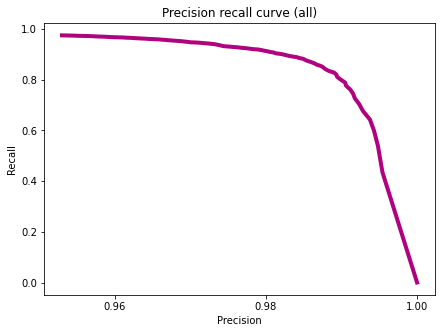

In [54]:
plot_pr_curve(precision_all, recall_all, 'Precision recall curve (all)')

**Quiz Question**: Among all the threshold values tried, what is the **smallest** threshold value that achieves a precision of 96.5% or better for the reviews of data in **baby_reviews**? Round your answer to 3 decimal places.

In [55]:
dataset.round(3)

,threshold_values,precision_all,recall_all
0,0.500,0.953,0.974
1,0.505,0.953,0.974
2,0.510,0.954,0.974
3,0.515,0.954,0.974
4,0.520,0.955,0.973
...,...,...,...
95,0.980,0.994,0.642
96,0.985,0.994,0.599
97,0.990,0.995,0.539
98,0.995,0.995,0.434


In [56]:
## Your Code
# Using For Loop for the range of row numbers of the DataFrame
for i in range(dataset.shape[0]):
    
# Checking the conditions under IF statement    
    if dataset.loc[i,'precision_all'] >= 0.965:
        dataset.loc[i,'Smallest_Threshold_Values'] = dataset.loc[i,'threshold_values']       

In [57]:
dataset['Smallest_Threshold_Values'].round(3).min()

0.657

**Quiz Question**: Using `threshold` = 0.98, how many **false negatives** do we get on the **test_data**? This is the number of false negatives (i.e the number of reviews to look at when not needed) that we have to deal with using this classifier.

In [58]:
## Your Code

# Calculating false negative reviews using 0.98 threshold
predictions_with_new_threshold = apply_threshold(probabilities, 0.98)
false_negatives = (np.array(test_data['Sentiment']) > 0) * (predictions_with_new_threshold < 0)
false_negatives.sum()

10233

In [59]:
from sklearn.metrics import confusion_matrix

cmat_098 = confusion_matrix(test_data['Sentiment'],
                        predictions_with_new_threshold)
  

print (' target_label | predicted_label | count ')
print ('--------------+-----------------+-------')
for i, target_label in enumerate(model.classes_):
    for j, predicted_label in enumerate(model.classes_):
        print ('{0:^13} | {1:^15} | {2:5d}'.format(target_label, predicted_label, cmat_098[i,j]))

 target_label | predicted_label | count 
--------------+-----------------+-------
     -1       |       -1        |  4718
     -1       |        1        |   114
      1       |       -1        | 10233
      1       |        1        | 18285


# Evaluating specific search terms

So far, we looked at the number of false positives for the **entire test set**. In this section, let's select reviews using a specific search term and optimize the precision on these reviews only. After all, a manufacturer would be interested in tuning the false positive rate just for their products (the reviews they want to read) rather than that of the entire set of products on Amazon.

## Precision-Recall on all baby related items

From the **test set**, select all the reviews for all products with the word 'baby' in them.

In [60]:
baby_reviews = test_data[test_data['name'].astype(str).apply(lambda x: 'baby' in x.lower())]

Now, let's predict the probability of classifying these reviews as positive. Make sure to convert the column review_clean of baby_reviews into a 2D array before computing class probability values. In scikit-learn, this task would be implemented as follows:

In [61]:
baby_matrix = vectorizer.transform(baby_reviews['review_clean'])
probabilities = model.predict_proba(baby_matrix)[:,1]

In [62]:
baby_matrix

<7813x122041 sparse matrix of type '<class 'numpy.int64'>'
	with 405507 stored elements in Compressed Sparse Row format>

Let's plot the precision-recall curve for the baby_reviews dataset. We again use 100 equally spaced values between 0.5 and 1 for the threshold.

In [63]:
threshold_values = np.linspace(0.5, 1, num=100)

For each of the values of threshold, we first obtain class predictions for baby_reviews using that threshold. Then we compute the precision and recall scores for baby_reviews. Save the precision scores and recall scores to lists precision_all and recall_all, respectively.



In [64]:
precision_all = []
recall_all = []

probabilities = model.predict_proba(baby_matrix)[:,1]
for threshold in threshold_values:
    
    ### Your Code
    predictions = apply_threshold(probabilities, threshold)
  
    recall_all.append(recall_score(y_true = baby_reviews['Sentiment'].values,
                      y_pred = predictions))

    precision_all.append(precision_score(y_true = baby_reviews['Sentiment'].values,
                      y_pred = predictions))

Quiz Question: Among all the threshold values tried, what is the smallest threshold value that achieves a precision of 96.5% or better for the reviews of data in baby_reviews? Round your answer to 3 decimal places.

In [65]:
dataset_baby = pd.DataFrame({'threshold_values': threshold_values, 'precision_all': precision_all,'recall_all': precision_all}, columns=['threshold_values', 'precision_all','recall_all'])
dataset_baby

,threshold_values,precision_all,recall_all
0,0.500000,0.946010,0.946010
1,0.505051,0.946418,0.946418
2,0.510101,0.947250,0.947250
3,0.515152,0.947384,0.947384
4,0.520202,0.948211,0.948211
...,...,...,...
95,0.979798,0.990747,0.990747
96,0.984848,0.990863,0.990863
97,0.989899,0.991326,0.991326
98,0.994949,0.993414,0.993414


In [66]:
## Your Code
dataset_baby.round(3)


,threshold_values,precision_all,recall_all
0,0.500,0.946,0.946
1,0.505,0.946,0.946
2,0.510,0.947,0.947
3,0.515,0.947,0.947
4,0.520,0.948,0.948
...,...,...,...
95,0.980,0.991,0.991
96,0.985,0.991,0.991
97,0.990,0.991,0.991
98,0.995,0.993,0.993


In [67]:
# Using For Loop for the range of row numbers of the DataFrame
for i in range(dataset_baby.shape[0]):
    
# Checking the conditions under IF statement    
    if dataset_baby.loc[i,'precision_all'] >= 0.965:
        dataset_baby.loc[i,'Smallest_Threshold_Values'] = dataset.loc[i,'threshold_values']    

In [68]:
dataset_baby['Smallest_Threshold_Values'].round(3).min()

0.717

Plot the precision-recall curve for baby_reviews only by running

C:\Users\sangita\AppData\Local\Temp/ipykernel_27936/3120609140.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(precision, recall, 'b-', linewidth=4.0, color = '#B0017F')


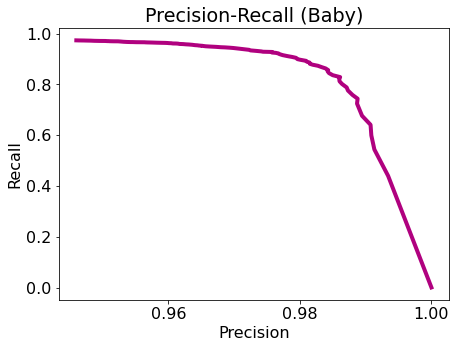

In [69]:
plot_pr_curve(precision_all, recall_all, "Precision-Recall (Baby)")